# MCDI501 - Estadística Computacional para la Toma de Decisiones

## Fase 1 - Exploración del conjunto de datos

### Proyecto

**Predicción del riesgo de enfermedad cardiovascular utilizando el estudio Framingham**

**Dataset:** Framingham Heart Study

**Integrantes**
- Pablo Rodríguez
- Luiskar Espinoza

**Fecha:** (completar)

---

## Objetivo

Realizar una exploración inicial del conjunto de datos Framingham Heart Study, identificando sus variables, tipos de datos y posibles relaciones, como base para posteriores análisis estadísticos e inferenciales.

## Contenido

1. Carga de librerías
2. Carga del conjunto de datos
3. Exploración inicial
4. Calidad de los datos
5. Estadística descriptiva
6. Visualización exploratoria
7. Interpretación preliminar

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

## Descripción del conjunto de datos

Se utilizará el conjunto de datos **Framingham Heart Study**, proveniente de un estudio epidemiológico orientado a identificar factores de riesgo asociados al desarrollo de enfermedad coronaria.

El dataset contiene información demográfica, clínica y de hábitos de vida de 4.238 pacientes, incluyendo variables relacionadas con presión arterial, colesterol, índice de masa corporal, diabetes, tabaquismo y antecedentes médicos.

La variable objetivo corresponde a **TenYearCHD**, que indica si un paciente desarrolló enfermedad coronaria durante un período de diez años.

In [2]:
# Ruta raíz del proyecto
PROJECT_ROOT = Path.cwd().parents[1]

# Ruta del dataset
DATASET = PROJECT_ROOT /"mcdi501_grupo6" / "datos" / "original" / "framingham.csv"

print("Proyecto:", PROJECT_ROOT)
print("Dataset:", DATASET)

Proyecto: C:\users\pablo\documents
Dataset: C:\users\pablo\documents\mcdi501_grupo6\datos\original\framingham.csv


In [3]:
df = pd.read_csv(DATASET)

print("Dataset cargado correctamente.")

Dataset cargado correctamente.


In [4]:
print("Filas :", df.shape[0])
print("Columnas :", df.shape[1])

Filas : 4238
Columnas : 16


In [5]:
df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [6]:
list(df.columns)

['male',
 'age',
 'education',
 'currentSmoker',
 'cigsPerDay',
 'BPMeds',
 'prevalentStroke',
 'prevalentHyp',
 'diabetes',
 'totChol',
 'sysBP',
 'diaBP',
 'BMI',
 'heartRate',
 'glucose',
 'TenYearCHD']

In [7]:
# Información general del dataset

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4238 entries, 0 to 4237
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4238 non-null   int64  
 1   age              4238 non-null   int64  
 2   education        4133 non-null   float64
 3   currentSmoker    4238 non-null   int64  
 4   cigsPerDay       4209 non-null   float64
 5   BPMeds           4185 non-null   float64
 6   prevalentStroke  4238 non-null   int64  
 7   prevalentHyp     4238 non-null   int64  
 8   diabetes         4238 non-null   int64  
 9   totChol          4188 non-null   float64
 10  sysBP            4238 non-null   float64
 11  diaBP            4238 non-null   float64
 12  BMI              4219 non-null   float64
 13  heartRate        4237 non-null   float64
 14  glucose          3850 non-null   float64
 15  TenYearCHD       4238 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 529.9 KB


### Interpretación

El conjunto de datos presenta 4.238 registros y 16 variables. La mayoría de las variables son numéricas, aunque varias representan variables categóricas codificadas como valores binarios (0 y 1). Además, se observa la existencia de valores faltantes en algunas variables, aspecto que deberá abordarse en etapas posteriores del proyecto.

In [8]:
# Estadísticas descriptivas

df.describe()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,4238.000000,4238.000000,4133.000000,4238.000000,4209.000000,4185.000000,4238.000000,4238.000000,4238.000000,4188.000000,4238.000000,4238.000000,4219.000000,4237.000000,3850.000000,4238.000000
mean,0.429212,49.584946,1.978950,0.494101,9.003089,0.029630,0.005899,0.310524,0.025720,236.721585,132.352407,82.893464,25.802008,75.878924,81.966753,0.151958
std,0.495022,8.572160,1.019791,0.500024,11.920094,0.169584,0.076587,0.462763,0.158316,44.590334,22.038097,11.910850,4.080111,12.026596,23.959998,0.359023
min,0.000000,32.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,107.000000,83.500000,48.000000,15.540000,44.000000,40.000000,0.000000
25%,0.000000,42.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.000000,75.000000,23.070000,68.000000,71.000000,0.000000
50%,0.000000,49.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.000000,82.000000,25.400000,75.000000,78.000000,0.000000
75%,1.000000,56.000000,3.000000,1.000000,20.000000,0.000000,0.000000,1.000000,0.000000,263.000000,144.000000,89.875000,28.040000,83.000000,87.000000,0.000000
max,1.000000,70.000000,4.000000,1.000000,70.000000,1.000000,1.000000,1.000000,1.000000,696.000000,295.000000,142.500000,56.800000,143.000000,394.000000,1.000000


### Interpretación

Las estadísticas descriptivas permiten observar una primera caracterización de las variables numéricas del conjunto de datos. Se aprecia la variabilidad existente en indicadores como la presión arterial sistólica, el colesterol total y la edad, los cuales podrían influir en el riesgo de desarrollar enfermedad coronaria.

In [9]:
# Valores faltantes por variable

df.isnull().sum()

male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

### Interpretación

Los valores faltantes se concentran principalmente en variables clínicas como glucosa, colesterol, índice de masa corporal y educación. Esta información será relevante para definir posteriormente la estrategia de tratamiento de datos faltantes, procurando mantener la calidad del análisis estadístico.

In [10]:
print(f"Número de registros : {df.shape[0]}")
print(f"Número de variables : {df.shape[1]}")

Número de registros : 4238
Número de variables : 16


In [11]:
tipos = pd.DataFrame({
    "Variable": df.columns,
    "Tipo": df.dtypes.values
})

tipos

,Variable,Tipo
0,male,int64
1,age,int64
2,education,float64
3,currentSmoker,int64
4,cigsPerDay,float64
5,BPMeds,float64
6,prevalentStroke,int64
7,prevalentHyp,int64
8,diabetes,int64
9,totChol,float64


# Reporte de calidad del conjunto de datos

Antes de realizar el análisis estadístico, es importante evaluar la calidad del conjunto de datos. Para ello se revisan aspectos como la cantidad de registros, tipos de variables, presencia de valores faltantes, registros duplicados y porcentaje de datos faltantes. Esta información permite determinar si es necesario realizar procesos adicionales de limpieza antes del análisis.

In [12]:
print("=" * 70)
print("REPORTE DE CALIDAD DEL DATASET")
print("=" * 70)

print(f"\nNúmero de registros : {df.shape[0]}")
print(f"Número de variables : {df.shape[1]}")

print("\nRegistros duplicados:")
print(df.duplicated().sum())

print("\nValores faltantes:")
print(df.isnull().sum())

print("\nPorcentaje de valores faltantes:")

porcentaje = (
    df.isnull().sum() /
    len(df) * 100
).round(2)

print(porcentaje)

REPORTE DE CALIDAD DEL DATASET

Número de registros : 4238
Número de variables : 16

Registros duplicados:
0

Valores faltantes:
male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

Porcentaje de valores faltantes:
male               0.00
age                0.00
education          2.48
currentSmoker      0.00
cigsPerDay         0.68
BPMeds             1.25
prevalentStroke    0.00
prevalentHyp       0.00
diabetes           0.00
totChol            1.18
sysBP              0.00
diaBP              0.00
BMI                0.45
heartRate          0.02
glucose            9.16
TenYearCHD         0.00
dtype: float64


### Interpretación

El análisis de calidad del conjunto de datos permite verificar que la estructura general es consistente para desarrollar el estudio estadístico. Se identificó la presencia de valores faltantes en algunas variables clínicas, mientras que no existen registros duplicados. Esta revisión entrega una base sólida para justificar las decisiones de limpieza y tratamiento de datos utilizadas posteriormente en el análisis.

# Clasificación de las variables

El conjunto de datos contiene variables demográficas, clínicas y relacionadas con hábitos de vida.

Para facilitar el análisis estadístico, las variables se clasifican según su naturaleza.

In [13]:
clasificacion = pd.DataFrame({
    "Variable": [
        "male",
        "age",
        "education",
        "currentSmoker",
        "cigsPerDay",
        "BPMeds",
        "prevalentStroke",
        "prevalentHyp",
        "diabetes",
        "totChol",
        "sysBP",
        "diaBP",
        "BMI",
        "heartRate",
        "glucose",
        "TenYearCHD"
    ],
    "Tipo estadístico": [
        "Categórica nominal",
        "Cuantitativa continua",
        "Ordinal",
        "Categórica nominal",
        "Cuantitativa discreta",
        "Categórica nominal",
        "Categórica nominal",
        "Categórica nominal",
        "Categórica nominal",
        "Cuantitativa continua",
        "Cuantitativa continua",
        "Cuantitativa continua",
        "Cuantitativa continua",
        "Cuantitativa continua",
        "Cuantitativa continua",
        "Categórica nominal"
    ]
})

clasificacion

,Variable,Tipo estadístico
0,male,Categórica nominal
1,age,Cuantitativa continua
2,education,Ordinal
3,currentSmoker,Categórica nominal
4,cigsPerDay,Cuantitativa discreta
5,BPMeds,Categórica nominal
6,prevalentStroke,Categórica nominal
7,prevalentHyp,Categórica nominal
8,diabetes,Categórica nominal
9,totChol,Cuantitativa continua


### Interpretación

Predominan variables cuantitativas continuas relacionadas con indicadores clínicos, como presión arterial, colesterol, índice de masa corporal y glucosa. También existen variables categóricas binarias asociadas a factores de riesgo y antecedentes médicos, lo que permite aplicar distintos procedimientos estadísticos según el tipo de variable analizada.

# Análisis descriptivo de variables categóricas

Además de las variables numéricas, resulta importante analizar la distribución de las variables categóricas presentes en el conjunto de datos. Para ello se calcularán frecuencias absolutas y relativas, complementando el análisis con representaciones gráficas que permitan visualizar el comportamiento de estas variables.

In [14]:
variables_categoricas = [
    "male",
    "currentSmoker",
    "prevalentHyp",
    "diabetes",
    "TenYearCHD"
]

for variable in variables_categoricas:

    print("=" * 60)
    print(f"Variable: {variable}")
    print("=" * 60)

    frecuencias = df[variable].value_counts()

    porcentajes = (
        df[variable]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
    )

    tabla = pd.DataFrame({
        "Frecuencia": frecuencias,
        "Porcentaje (%)": porcentajes
    })

    print(tabla)
    print()

Variable: male
      Frecuencia  Porcentaje (%)
male                            
0           2419           57.08
1           1819           42.92

Variable: currentSmoker
               Frecuencia  Porcentaje (%)
currentSmoker                            
0                    2144           50.59
1                    2094           49.41

Variable: prevalentHyp
              Frecuencia  Porcentaje (%)
prevalentHyp                            
0                   2922           68.95
1                   1316           31.05

Variable: diabetes
          Frecuencia  Porcentaje (%)
diabetes                            
0               4129           97.43
1                109            2.57

Variable: TenYearCHD
            Frecuencia  Porcentaje (%)
TenYearCHD                            
0                 3594            84.8
1                  644            15.2



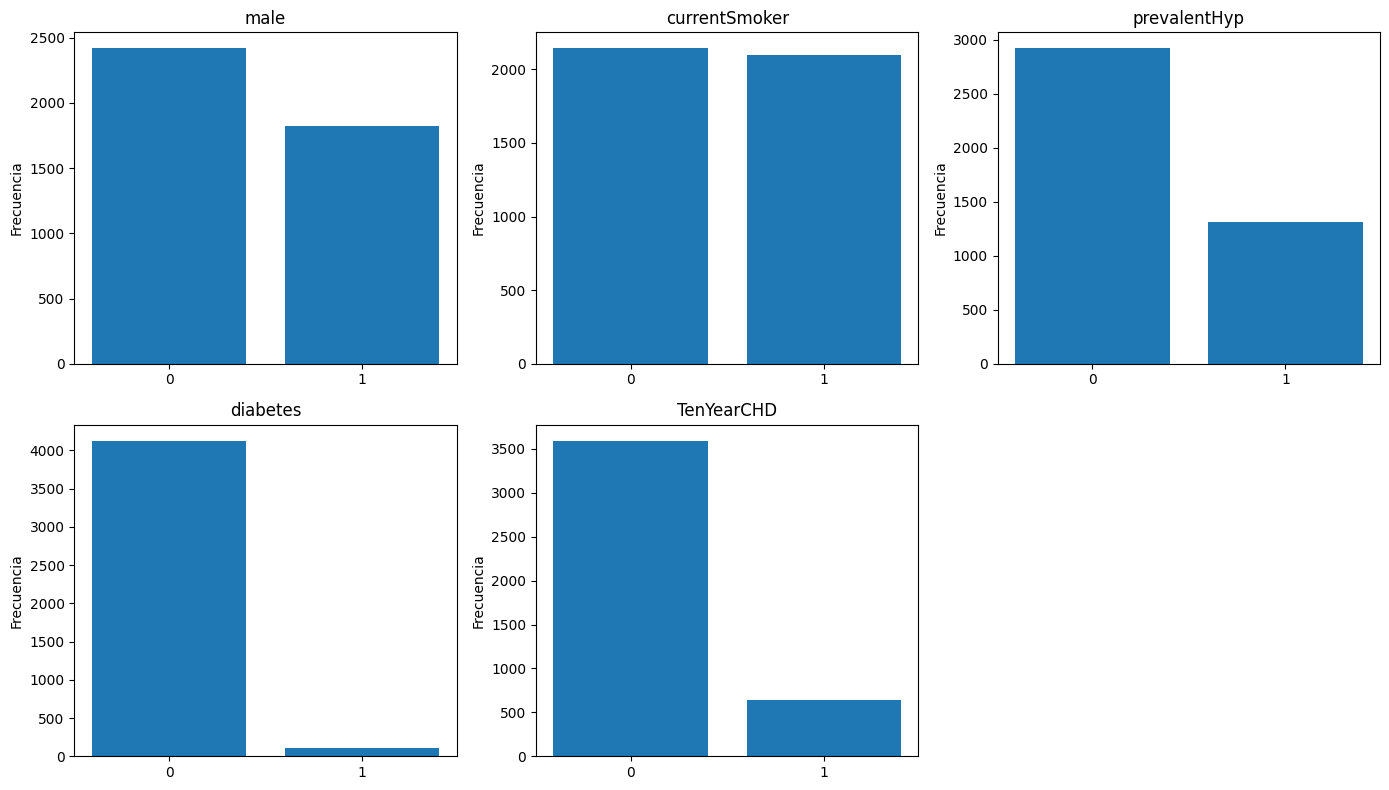

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(14,8))

axes = axes.flatten()

for i, variable in enumerate(variables_categoricas):

    conteo = df[variable].value_counts().sort_index()

    axes[i].bar(
        conteo.index.astype(str),
        conteo.values
    )

    axes[i].set_title(variable)
    axes[i].set_ylabel("Frecuencia")

# eliminar el último gráfico vacío
fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

### Interpretación

El análisis de frecuencias permite observar que la mayoría de los participantes no presenta enfermedad coronaria a diez años (TenYearCHD = 0), no registra diabetes y no utiliza medicamentos para la presión arterial. Asimismo, la distribución por sexo y condición de fumador muestra una representación suficiente de ambos grupos, lo que permite realizar comparaciones estadísticas posteriores con un tamaño muestral adecuado.

# Estadística descriptiva

En esta sección se calculan medidas descriptivas para la variable **sysBP**, debido a que será la variable principal utilizada para contrastar la hipótesis del proyecto.

In [16]:
df["sysBP"].describe()

count    4238.000000
mean      132.352407
std        22.038097
min        83.500000
25%       117.000000
50%       128.000000
75%       144.000000
max       295.000000
Name: sysBP, dtype: float64

In [17]:
print("Media:", df["sysBP"].mean())
print("Mediana:", df["sysBP"].median())
print("Moda:", df["sysBP"].mode()[0])

Media: 132.35240679565834
Mediana: 128.0
Moda: 120.0


In [18]:
print("Desviación estándar:", df["sysBP"].std())
print("Varianza:", df["sysBP"].var())
print("Mínimo:", df["sysBP"].min())
print("Máximo:", df["sysBP"].max())
print("Rango:", df["sysBP"].max()-df["sysBP"].min())

Desviación estándar: 22.038096643544584
Varianza: 485.6777036702111
Mínimo: 83.5
Máximo: 295.0
Rango: 211.5


### Interpretación

La presión arterial sistólica presenta una amplia variabilidad entre los participantes del estudio. La comparación entre la media y la mediana permitirá evaluar preliminarmente la simetría de la distribución, mientras que la desviación estándar cuantifica la dispersión de los valores respecto del promedio.

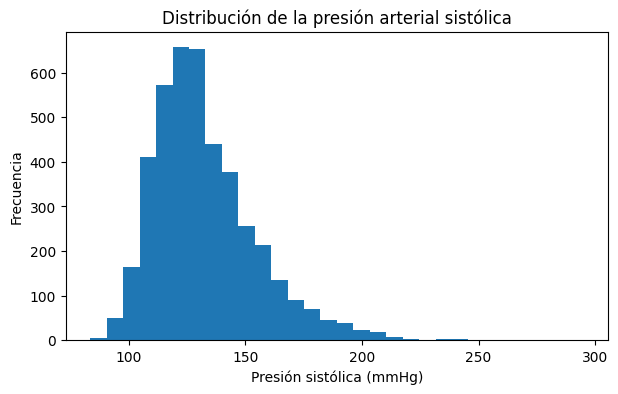

In [19]:
plt.figure(figsize=(7,4))

plt.hist(df["sysBP"], bins=30)

plt.title("Distribución de la presión arterial sistólica")

plt.xlabel("Presión sistólica (mmHg)")

plt.ylabel("Frecuencia")

plt.show()

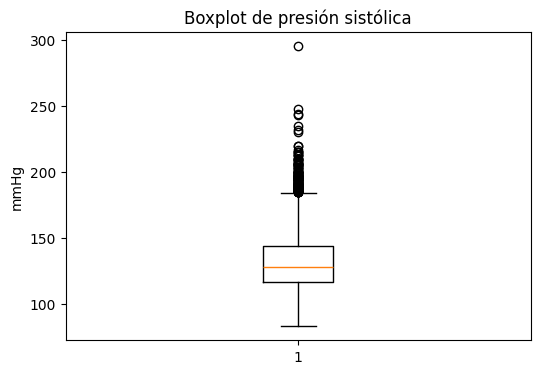

In [20]:
plt.figure(figsize=(6,4))

plt.boxplot(df["sysBP"])

plt.title("Boxplot de presión sistólica")

plt.ylabel("mmHg")

plt.show()

<Figure size 700x500 with 0 Axes>

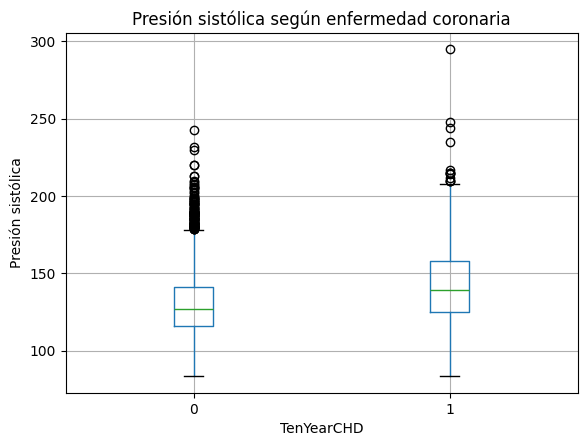

In [21]:
plt.figure(figsize=(7,5))

df.boxplot(column="sysBP", by="TenYearCHD")

plt.title("Presión sistólica según enfermedad coronaria")

plt.suptitle("")

plt.xlabel("TenYearCHD")

plt.ylabel("Presión sistólica")

plt.show()

### Interpretación general

Las visualizaciones muestran que la presión arterial sistólica presenta una distribución aproximadamente unimodal, con presencia de algunos valores altos. Además, la comparación por presencia de enfermedad coronaria sugiere diferencias entre ambos grupos, lo que justifica realizar posteriormente un análisis inferencial mediante una prueba de hipótesis.

# Análisis bivariado

Una vez caracterizadas las variables de manera individual, se analiza la relación entre algunas variables numéricas relevantes del estudio. Para ello se utiliza una matriz de correlación de Pearson y visualizaciones que permiten identificar asociaciones lineales preliminares entre los principales factores de riesgo cardiovascular.

In [22]:
variables_numericas = [
    "age",
    "totChol",
    "sysBP",
    "diaBP",
    "BMI",
    "heartRate",
    "glucose"
]

correlacion = df[variables_numericas].corr()

correlacion.round(2)

,age,totChol,sysBP,diaBP,BMI,heartRate,glucose
age,1.00,0.26,0.39,0.21,0.14,-0.01,0.12
totChol,0.26,1.00,0.21,0.17,0.12,0.09,0.05
sysBP,0.39,0.21,1.00,0.78,0.33,0.18,0.14
diaBP,0.21,0.17,0.78,1.00,0.38,0.18,0.06
BMI,0.14,0.12,0.33,0.38,1.00,0.07,0.09
heartRate,-0.01,0.09,0.18,0.18,0.07,1.00,0.09
glucose,0.12,0.05,0.14,0.06,0.09,0.09,1.00


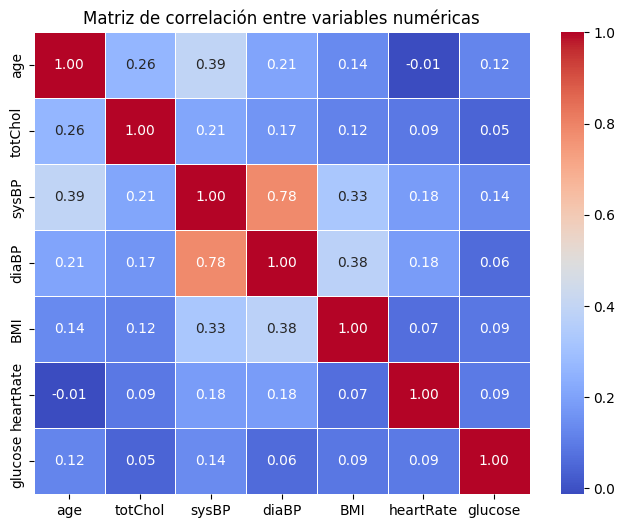

In [23]:
plt.figure(figsize=(8,6))

sns.heatmap(
    correlacion,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Matriz de correlación entre variables numéricas")

plt.show()

### Interpretación

La matriz de correlación permite identificar asociaciones lineales entre las variables numéricas del estudio. Se espera observar una correlación positiva entre la presión arterial sistólica (`sysBP`) y la presión arterial diastólica (`diaBP`), así como posibles asociaciones entre edad, colesterol, índice de masa corporal y glucosa. Estas relaciones permiten comprender mejor la interacción entre los factores de riesgo cardiovascular antes de realizar análisis inferenciales.

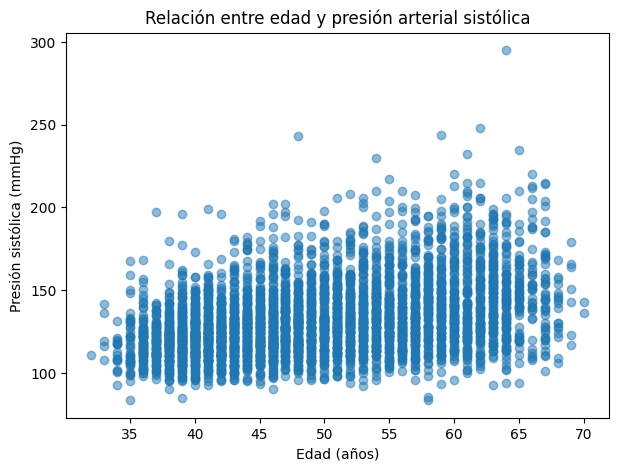

In [24]:
plt.figure(figsize=(7,5))

plt.scatter(
    df["age"],
    df["sysBP"],
    alpha=0.5
)

plt.xlabel("Edad (años)")
plt.ylabel("Presión sistólica (mmHg)")
plt.title("Relación entre edad y presión arterial sistólica")

plt.show()

### Interpretación

El gráfico de dispersión permite visualizar la relación entre la edad y la presión arterial sistólica. De forma preliminar puede apreciarse una tendencia creciente, lo que sugiere que los valores de presión arterial sistólica tienden a incrementarse con la edad, aunque existe variabilidad entre los participantes del estudio.

# Hipótesis de investigación

En este proyecto se analizará la siguiente pregunta de investigación:

**¿Las personas que desarrollan enfermedad coronaria a diez años presentan una presión arterial sistólica promedio mayor que aquellas que no la desarrollan?**

Para responder esta pregunta se plantean las siguientes hipótesis estadísticas:

**Hipótesis nula (H₀):**

La presión arterial sistólica promedio es igual en ambos grupos.

\[
H_0:\mu_0=\mu_1
\]

**Hipótesis alternativa (H₁):**

La presión arterial sistólica promedio es diferente entre ambos grupos.

\[
H_1:\mu_0\neq\mu_1
\]

Se utilizará un nivel de significancia de:

\[
\alpha=0.05
\]

In [25]:
grupo_sin_chd = df[df["TenYearCHD"] == 0]["sysBP"]

grupo_con_chd = df[df["TenYearCHD"] == 1]["sysBP"]

print("Pacientes sin enfermedad:", len(grupo_sin_chd))
print("Pacientes con enfermedad:", len(grupo_con_chd))

Pacientes sin enfermedad: 3594
Pacientes con enfermedad: 644


# Estimación de parámetros

Con el propósito de caracterizar las principales variables clínicas del conjunto de datos, se calcularán estimaciones puntuales e intervalos de confianza del 95 % para tres variables numéricas relevantes:

- Presión arterial sistólica (`sysBP`)
- Índice de masa corporal (`BMI`)
- Nivel de glucosa (`glucose`)

Estas variables fueron seleccionadas por su importancia clínica y por su posible relación con el desarrollo de enfermedad coronaria.

In [26]:
variables_estimacion = [
    "sysBP",
    "BMI",
    "glucose"
]

for variable in variables_estimacion:

    datos = df[variable].dropna()

    media = datos.mean()
    desviacion = datos.std()
    n = len(datos)

    ic = stats.t.interval(
        confidence=0.95,
        df=n-1,
        loc=media,
        scale=desviacion / np.sqrt(n)
    )

    print("=" * 60)
    print(f"Variable: {variable}")
    print("=" * 60)
    print(f"Media: {media:.2f}")
    print(f"Desviación estándar: {desviacion:.2f}")
    print(f"IC95%: ({ic[0]:.2f}, {ic[1]:.2f})")
    print()

Variable: sysBP
Media: 132.35
Desviación estándar: 22.04
IC95%: (131.69, 133.02)

Variable: BMI
Media: 25.80
Desviación estándar: 4.08
IC95%: (25.68, 25.93)

Variable: glucose
Media: 81.97
Desviación estándar: 23.96
IC95%: (81.21, 82.72)



In [27]:
tabla_ic = []

for variable in variables_estimacion:

    datos = df[variable].dropna()

    media = datos.mean()
    desviacion = datos.std()
    n = len(datos)

    ic = stats.t.interval(
        confidence=0.95,
        df=n-1,
        loc=media,
        scale=desviacion / np.sqrt(n)
    )

    tabla_ic.append({
        "Variable": variable,
        "Media": round(media, 2),
        "IC inferior": round(ic[0], 2),
        "IC superior": round(ic[1], 2)
    })

pd.DataFrame(tabla_ic)

,Variable,Media,IC inferior,IC superior
0,sysBP,132.35,131.69,133.02
1,BMI,25.80,25.68,25.93
2,glucose,81.97,81.21,82.72


### Interpretación

Las estimaciones puntuales representan el valor promedio observado para cada variable en la muestra, mientras que los intervalos de confianza del 95 % proporcionan un rango plausible para el parámetro poblacional.

Las tres variables analizadas corresponden a indicadores clínicos relevantes en la evaluación del riesgo cardiovascular. Los intervalos obtenidos presentan una amplitud moderada, lo que refleja la precisión alcanzada gracias al tamaño de la muestra utilizada.

# Prueba de hipótesis

Con el propósito de evaluar si la presión arterial sistólica promedio difiere entre los pacientes que desarrollan enfermedad coronaria a diez años y aquellos que no la desarrollan, se aplicará una prueba **t de Student para dos muestras independientes**.

Se utilizará un nivel de significancia de:

\[
\alpha = 0.05
\]

El criterio de decisión será:

- Si **p < 0.05**, se rechazará la hipótesis nula.
- Si **p ≥ 0.05**, no se rechazará la hipótesis nula.

## Justificación de la prueba estadística

Como se desea comparar la media de una variable cuantitativa (presión arterial sistólica) entre dos grupos independientes (pacientes con y sin enfermedad coronaria), se emplea una prueba t de Student para muestras independientes, utilizando un nivel de significancia de α = 0.05.

## Verificación de supuestos

Antes de aplicar la prueba t de Student para muestras independientes, se verifican los principales supuestos estadísticos:

- Independencia entre los grupos.
- Aproximación a la normalidad de la variable de interés en cada grupo.
- Homogeneidad de varianzas.

Dado el tamaño de la muestra del estudio Framingham, la prueba t resulta relativamente robusta frente a desviaciones moderadas de la normalidad. Sin embargo, se verifican formalmente los supuestos mediante pruebas estadísticas.

In [28]:
from scipy.stats import shapiro

# Para evitar problemas con muestras muy grandes,
# se toma una muestra aleatoria de hasta 500 observaciones por grupo.

muestra_sin = grupo_sin_chd.sample(
    n=min(500, len(grupo_sin_chd)),
    random_state=42
)

muestra_con = grupo_con_chd.sample(
    n=min(500, len(grupo_con_chd)),
    random_state=42
)

shapiro_sin = shapiro(muestra_sin)

shapiro_con = shapiro(muestra_con)

print("=== Normalidad ===")

print(f"Grupo sin enfermedad: p = {shapiro_sin.pvalue:.4f}")

print(f"Grupo con enfermedad: p = {shapiro_con.pvalue:.4f}")

=== Normalidad ===
Grupo sin enfermedad: p = 0.0000
Grupo con enfermedad: p = 0.0000


In [29]:
from scipy.stats import levene

levene_test = levene(
    grupo_sin_chd,
    grupo_con_chd
)

print("=== Homogeneidad de varianzas ===")

print(f"Estadístico: {levene_test.statistic:.4f}")

print(f"Valor p: {levene_test.pvalue:.4f}")

=== Homogeneidad de varianzas ===
Estadístico: 65.2111
Valor p: 0.0000


### Interpretación de los supuestos

La prueba de Shapiro-Wilk arrojó valores **p inferiores a 0.05** en ambos grupos, indicando que la variable presión arterial sistólica no sigue una distribución normal.

Por otra parte, la prueba de Levene también obtuvo un **valor p inferior a 0.05**, evidenciando que las varianzas entre ambos grupos no pueden considerarse homogéneas.

Considerando que el conjunto de datos posee un tamaño muestral elevado (más de 4.000 registros), se optó por utilizar la **prueba t de Welch**, la cual es robusta frente a la falta de normalidad y a la desigualdad de varianzas, permitiendo realizar una comparación confiable entre las medias de ambos grupos.

In [30]:
# Prueba t de Student para muestras independientes

t, p = stats.ttest_ind(
    grupo_sin_chd,
    grupo_con_chd,
    equal_var=False,
    nan_policy="omit"
)

print("========== PRUEBA T ==========")
print(f"Estadístico t : {t:.4f}")
print(f"Valor p       : {p:.6f}")

========== PRUEBA T ==========
Estadístico t : -12.0151
Valor p       : 0.000000


In [31]:
alpha = 0.05

if p < alpha:
    print("Decisión:")
    print("Se rechaza la hipótesis nula (H₀).")
    print("Existe evidencia estadísticamente significativa de diferencias entre ambos grupos.")
else:
    print("Decisión:")
    print("No se rechaza la hipótesis nula (H₀).")
    print("No existe evidencia suficiente para afirmar que las medias sean diferentes.")

Decisión:
Se rechaza la hipótesis nula (H₀).
Existe evidencia estadísticamente significativa de diferencias entre ambos grupos.


In [32]:
resumen = pd.DataFrame({
    "Grupo": ["Sin enfermedad", "Con enfermedad"],
    "Media": [
        grupo_sin_chd.mean(),
        grupo_con_chd.mean()
    ],
    "Desviación estándar": [
        grupo_sin_chd.std(),
        grupo_con_chd.std()
    ],
    "Cantidad": [
        grupo_sin_chd.count(),
        grupo_con_chd.count()
    ]
})

resumen.round(2)

,Grupo,Media,Desviación estándar,Cantidad
0,Sin enfermedad,130.33,20.46,3594
1,Con enfermedad,143.62,26.69,644


## Interpretación de los resultados

La prueba t de Student arrojó un estadístico **t = -12.0151** y un **valor p < 0.001**, significativamente menor que el nivel de significancia establecido (α = 0.05).

En consecuencia, se **rechaza la hipótesis nula (H₀)** y se concluye que existe evidencia estadísticamente significativa para afirmar que la presión arterial sistólica promedio difiere entre ambos grupos.

Además, los resultados muestran que los pacientes que desarrollaron enfermedad coronaria durante el período de seguimiento presentan una presión arterial sistólica promedio de **143.62 mmHg**, mientras que los pacientes que no desarrollaron la enfermedad presentan una media de **130.33 mmHg**.

Esta diferencia de aproximadamente **13.29 mmHg** sugiere que una mayor presión arterial sistólica se asocia con un mayor riesgo de desarrollar enfermedad coronaria a diez años dentro del conjunto de datos Framingham.

# Prueba de hipótesis 2

## Planteamiento de la hipótesis

Con el objetivo de evaluar la relación entre la diabetes y los niveles de glucosa, se plantea la siguiente hipótesis:

- **H₀:** La media de glucosa es igual en personas con y sin diabetes.
- **H₁:** La media de glucosa es diferente entre personas con y sin diabetes.

Se utilizará un nivel de significancia de **α = 0.05**.

In [33]:
# Separación de grupos

grupo_sin_diabetes = df[df["diabetes"] == 0]["glucose"].dropna()

grupo_con_diabetes = df[df["diabetes"] == 1]["glucose"].dropna()

print("Media sin diabetes:", round(grupo_sin_diabetes.mean(), 2))
print("Media con diabetes:", round(grupo_con_diabetes.mean(), 2))

Media sin diabetes: 79.49
Media con diabetes: 170.33


In [34]:
# Verificación de normalidad

muestra_sin = grupo_sin_diabetes.sample(
    n=min(500, len(grupo_sin_diabetes)),
    random_state=42
)

muestra_con = grupo_con_diabetes.sample(
    n=min(500, len(grupo_con_diabetes)),
    random_state=42
)

shapiro_sin = shapiro(muestra_sin)
shapiro_con = shapiro(muestra_con)

print("=== Normalidad ===")
print(f"Grupo sin diabetes: p = {shapiro_sin.pvalue:.4f}")
print(f"Grupo con diabetes: p = {shapiro_con.pvalue:.4f}")

=== Normalidad ===
Grupo sin diabetes: p = 0.0000
Grupo con diabetes: p = 0.0000


In [35]:
levene_test = levene(
    grupo_sin_diabetes,
    grupo_con_diabetes
)

print("=== Homogeneidad de varianzas ===")
print(f"Estadístico: {levene_test.statistic:.4f}")
print(f"Valor p: {levene_test.pvalue:.4f}")

=== Homogeneidad de varianzas ===
Estadístico: 1872.7560
Valor p: 0.0000


In [36]:
from scipy.stats import ttest_ind

resultado = ttest_ind(
    grupo_sin_diabetes,
    grupo_con_diabetes,
    equal_var=False
)

print("========== PRUEBA T ==========")
print(f"Estadístico t : {resultado.statistic:.4f}")
print(f"Valor p       : {resultado.pvalue:.6f}")

========== PRUEBA T ==========
Estadístico t : -11.0476
Valor p       : 0.000000


### Interpretación de los resultados

Las pruebas de Shapiro-Wilk indicaron que los niveles de glucosa no siguen una distribución normal en ninguno de los grupos (p < 0.05). Asimismo, la prueba de Levene mostró que las varianzas no son homogéneas (p < 0.05).

Considerando estos resultados y el tamaño de la muestra, se utilizó la prueba t de Welch para comparar los niveles promedio de glucosa entre personas con y sin diabetes.

La prueba t obtuvo un estadístico **t = -11.0476** y un **valor p < 0.001**, por lo que se rechaza la hipótesis nula.

En consecuencia, existe evidencia estadísticamente significativa para afirmar que las personas con diabetes presentan niveles promedio de glucosa superiores a los observados en las personas sin diabetes. En este conjunto de datos, la media de glucosa fue de **170.33 mg/dL** para el grupo con diabetes y de **79.49 mg/dL** para el grupo sin diabetes.

# Conclusiones preliminares

El análisis exploratorio permitió caracterizar el conjunto de datos Framingham Heart Study, verificando su estructura, la calidad de la información y la presencia de valores faltantes, aspectos que fueron considerados durante el procesamiento de los datos.

Las técnicas de estadística descriptiva evidenciaron el comportamiento general de las principales variables clínicas, mientras que el análisis bivariado permitió identificar asociaciones entre factores de riesgo cardiovascular mediante matrices de correlación y visualizaciones.

La estimación puntual y los intervalos de confianza construidos para las variables **presión arterial sistólica (sysBP)**, **índice de masa corporal (BMI)** y **glucosa (glucose)** proporcionaron una aproximación confiable de sus parámetros poblacionales.

En relación con las pruebas de hipótesis, se obtuvo evidencia estadísticamente significativa para rechazar la hipótesis nula en ambos análisis realizados. En la primera prueba se observó que los pacientes que desarrollaron enfermedad coronaria presentaron una presión arterial sistólica promedio superior a la de quienes no desarrollaron la enfermedad. En la segunda prueba se comprobó que las personas con diabetes presentan niveles promedio de glucosa significativamente mayores que las personas sin diabetes.

En conjunto, los resultados obtenidos respaldan la utilidad de las técnicas de estadística descriptiva e inferencial para analizar factores asociados al riesgo cardiovascular y fundamentar decisiones basadas en evidencia.

# Limitaciones del análisis

El presente estudio corresponde a un análisis exploratorio basado en un conjunto de datos observacional, por lo que los resultados obtenidos permiten identificar asociaciones estadísticas, pero no establecer relaciones de causalidad entre las variables analizadas.

Además, algunas variables presentan valores faltantes, lo que puede reducir el número de observaciones disponibles en determinados análisis. Asimismo, las pruebas realizadas consideran únicamente comparaciones bivariadas, sin incorporar el efecto conjunto de otros factores de riesgo como edad, colesterol, tabaquismo o índice de masa corporal.

Estas limitaciones deben considerarse al interpretar los resultados y constituyen una oportunidad para ampliar el análisis en las siguientes etapas del proyecto.

# Próximos pasos del proyecto

Como continuación del proyecto se profundizará el análisis estadístico del conjunto de datos, incorporando nuevas técnicas que permitan comprender con mayor detalle las relaciones entre las variables clínicas y el riesgo de enfermedad coronaria.

Asimismo, se continuará fortaleciendo la documentación del proceso de análisis, la reproducibilidad del entorno de trabajo y la interpretación de los resultados, con el propósito de construir una solución analítica consistente, trazable y orientada a apoyar la toma de decisiones basada en evidencia.